# Tensile Stress Peak Migration — Power-Law Scaling Analysis

The tensile stress migrates in time according to a power-law relationship:

$$
d(t) = A\, t^{\alpha},
$$

where $d(t)$ is the peak position, $A$ is a prefactor, and $\alpha$ is the time-scaling exponent.

---

## Objective

In this notebook I examine:

- how the time exponent $\alpha$ depends on:
  - the **applied injection rate** $q_0$,
  - the **initial fracture aperture** $w_i$.
- if there is a **semi-analytical** (similarity) solution
- the **velocity vs. duration** analysis

---

## Base Physical Parameters

| Property | Value |
| --- | --- |
| Fracture length, $L$ | 100 m |
| Normal stiffness, $k_n$ | 50 GPa/m |
| Initial aperture, $w_i$ | 0.1 mm |
| Viscosity, $\mu$ | $10^{-3}$ Pa·s |
| Applied injection rate, $q_0$ | $10^{-5}$ m$^2$/s |
| Young’s modulus, $E$ | 60 GPa |
| Poisson’s ratio, $\nu$ | 0.25 |

---

## Approach to find $\alpha$

For each simulation:

1. I extract the tensile stress peak position $d(t)$ over time.
2. I fit a power law $d(t) = A t^{\alpha}$.
3. I analyze the exponent $\alpha$ as a function of:
   - injection rate $q_0$,
   - initial aperture $w_i$ (and corresponding permeability $k = w_i^2/12$).

---


In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# -------------------------------------------------------------------
# Utilities (front + fitting + file IO)
# -------------------------------------------------------------------

def power_law(t, A, alpha):
    return A * t**alpha

def find_front(x, sn_tx):
    # front = location of minimum normal stress per time step
    return x[np.argmin(sn_tx, axis=1)]

def cut_before_boundary(front, t, L, buffer=1.0):
    m = front < (L - buffer)
    return front[m], t[m]

def fit_front_power_law(t, front):
    t = np.asarray(t)
    front = np.asarray(front)
    m = t > 0
    t, front = t[m], front[m]
    (A, alpha), _ = curve_fit(power_law, t, front, p0=(front.max(), 0.8), maxfev=20_000)
    return A, alpha

def read_run(fp: Path):
    with h5py.File(fp, "r") as f:
        x_el = f["coordinates"]["x_elastic"][:]
        t = f["coordinates"]["t"][:]
        sn_tx = f["fields"]["stress_normal"][:]
        params = {k: f["parameters"][k][()] for k in f["parameters"].keys()}
    return x_el, t, sn_tx, params

def analyze_run(fp: Path, *, buffer=1.0, t_slice=None):
    x_el, t, sn_tx, params = read_run(fp)
    L = float(params["L"])
    front = find_front(x_el, sn_tx)
    front, t = cut_before_boundary(front, t, L, buffer=buffer)

    if t_slice is not None:
        front = front[t_slice]
        t = t[t_slice]

    A, alpha = fit_front_power_law(t, front)
    return {"file": fp.name, "A": A, "alpha": alpha, "front": front, "t": t, **params}

In [3]:
# -------------------------------------------------------------------
# Importing results of alpha for injection rate effect analysis
# -------------------------------------------------------------------

result_dir = Path.cwd() / "results" / "fvm-elastic" / "runs"
files_q0 = [
    result_dir / "run-q-1e-06.hdf5",
    result_dir / "run-q-1e-05.hdf5",
    result_dir / "run-q-1e-04.hdf5",
    result_dir / "run-q-1e-03.hdf5",
]

results_q0 = []
for fp in files_q0:
    if not fp.exists():
        print(f"Missing: {fp.name}")
        continue
    results_q0.append(analyze_run(fp, buffer=1.0))

results_q0 = sorted(results_q0, key=lambda d: d["q_0"])
for r in results_q0:
    print(f"{r['file']}: q0={r['q_0']:.1e}  A={r['A']:.4g}  alpha={r['alpha']:.4g}")

run-q-1e-06.hdf5: q0=1.0e-06  A=3.912  alpha=0.5018
run-q-1e-05.hdf5: q0=1.0e-05  A=3.629  alpha=0.5708
run-q-1e-04.hdf5: q0=1.0e-04  A=4.621  alpha=0.6609
run-q-1e-03.hdf5: q0=1.0e-03  A=9.054  alpha=0.7314


In [4]:
# -------------------------------------------------------------------
# Importing results of alpha for initial aperture analysis
# -------------------------------------------------------------------
files_wi = [
    result_dir / "run-wi-1e-05.hdf5",
    result_dir / "run-wi-5e-05.hdf5",
    result_dir / "run-q-1e-05.hdf5",  # baseline
]

results_wi = []
for fp in files_wi:
    if not fp.exists():
        print(f"Missing: {fp.name}")
        continue
    r = analyze_run(fp, buffer=1.0)
    if "w_i" not in r:
        print(f"No w_i in {fp.name}")
        continue
    results_wi.append(r)

results_wi = sorted(results_wi, key=lambda d: d["w_i"])
for r in results_wi:
    print(f"{r['file']}: w_i={r['w_i']:.1e}  A={r['A']:.4g}  alpha={r['alpha']:.4g}")

run-wi-1e-05.hdf5: w_i=1.0e-05  A=0.3208  alpha=0.8179
run-wi-5e-05.hdf5: w_i=5.0e-05  A=1.279  alpha=0.6742
run-q-1e-05.hdf5: w_i=1.0e-04  A=3.629  alpha=0.5708


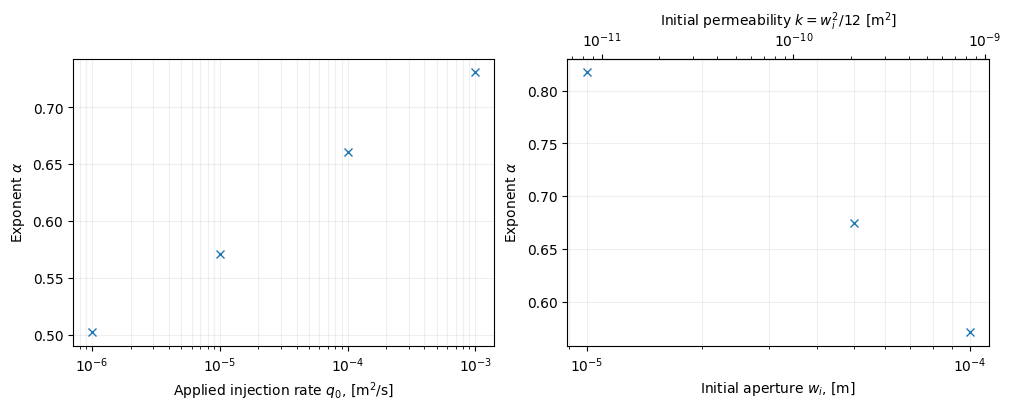

In [5]:
# -------------------------------------------------------------------
# Plot alpha vs q_0 and w_i
# -------------------------------------------------------------------

q0 = np.array([r["q_0"] for r in results_q0])
alpha_q0 = np.array([r["alpha"] for r in results_q0])

wi = np.array([r["w_i"] for r in results_wi])
alpha_wi = np.array([r["alpha"] for r in results_wi])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# ---- Left: alpha vs q0
ax1.plot(q0, alpha_q0, "x", label="runs")
ax1.set_xscale("log")
ax1.set_xlabel(r"Applied injection rate $q_0$, [m$^2$/s]")
ax1.set_ylabel(r"Exponent $\alpha$")
ax1.grid(True, which="both", alpha=0.2)


# ---- Right: alpha vs wi
ax2.plot(wi, alpha_wi, "x")
ax2.set_xscale("log")
ax2.set_xlabel(r"Initial aperture $w_i$, [m]")
ax2.set_ylabel(r"Exponent $\alpha$")
ax2.grid(True, which="both", alpha=0.2)

secax = ax2.secondary_xaxis(
    "top",
    functions=(lambda w: w**2 / 12.0, lambda k: np.sqrt(12.0 * k)),
)
secax.set_xlabel(r"Initial permeability $k=w_i^2/12$ [m$^2$]")
secax.set_xscale("log")

plt.show()

## Analytical (self-similar) scaling for front migration

### Similarity formulation

Murphy et al. (2004) applied the Buckingham $\Pi$ theorem to the nonlinear diffusion equation (with exponent $n = 3$) and derived the following similarity variables:

$$
\theta(\zeta) = \frac{w(x,t)}{(q^2 t / a)^{1/5}},
\qquad
\zeta = \frac{x}{(a q_0^3 t^4)^{1/5}}
$$

The characteristic aperture scale is

$$
w^* = (q^2 t / a)^{1/5}.
$$

---

### Effect of non-zero initial aperture

In our problem, the fracture has a non-zero initial aperture $w_i$.  
For a semi-infinite fracture, the solution must satisfy:

$$
\lim_{\zeta \to \infty} \theta(\zeta)
=
\frac{w_i}{(q^2 t / a)^{1/5}}
=
\frac{w_i}{w^*}.
$$

Because $w^*$ depends on time, this boundary condition is time-dependent.  
Therefore, the problem is **not strictly self-similar**.

However, if the initial aperture is small compared to the characteristic aperture,

$$
w_i \ll w^*,
$$

then:

$$
\frac{w_i}{w^*} \approx 0.
$$

In that case, the far-field condition becomes effectively zero, and the problem **becomes self-similar**.

---

### Scaling law for front migration

Using the similarity variables, the front position evolves as

$$
d(t) = \zeta_f (a q_0^3 t^4)^{1/5},
\qquad
a = \frac{k_n}{12\mu},
\qquad
\zeta_f \approx 1.
$$

which predicts a theoretical exponent

$$
\alpha = \frac{4}{5},
$$

and prefactor

$$
A = \left( \frac{k_n}{12\mu} q_0^3 \right)^{1/5}.
$$

---

### Comparison with numerical results

For the case $w_i = 0.01$ mm, the condition $w_i \ll w^*$ is satisfied over the simulation time window. Therefore, the similarity solution should be applicable.

---

### Summary

- A non-zero initial aperture formally breaks strict self-similarity.
- If $w_i \ll w^*$, the problem becomes asymptotically self-similar.
- In that regime, the tensile peak migration follows:
  
  $$
  d(t) \sim t^{4/5}
  $$

- The prefactor depends only on $k_n$, $\mu$, and $q_0$.

fit:  A=0.3208, alpha=0.8179
semi: A=0.3342, alpha=0.8


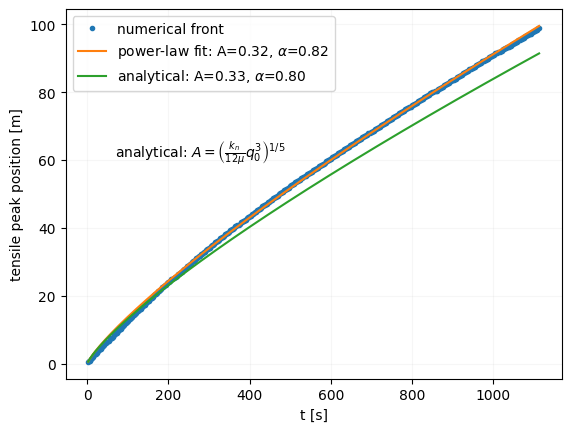

In [6]:
# -------------------------------------------------------------------
# Comparison of numerical results with Murphy style semi-analytical solution
# -------------------------------------------------------------------

r = analyze_run(result_dir / "run-wi-1e-05.hdf5", buffer=1.0)

alpha_semi = 4/5
a = r["k_n"] / (12.0 * r["mu"])
A_semi = (a * r["q_0"]**3)**(1/5)

print(f"fit:  A={r['A']:.4g}, alpha={r['alpha']:.4g}")
print(f"semi: A={A_semi:.4g}, alpha={alpha_semi:.4g}")

fig, ax = plt.subplots()
ax.plot(r["t"], r["front"], ".", label="numerical front")
ax.plot(r["t"], power_law(r["t"], r["A"], r["alpha"]), label=f"power-law fit: A={r['A']:.2f}, $\\alpha$={r['alpha']:.2f}")
ax.plot(r["t"], power_law(r["t"], A_semi, alpha_semi), label=f"analytical: A={A_semi:.2f}, $\\alpha$={alpha_semi:.2f}")
ax.text(0.1, 0.6, "analytical: $A = \\left(\\frac{k_n}{12\\mu} q_0^3 \\right)^{1/5}$", transform=ax.transAxes)
ax.set_xlabel("t [s]")
ax.set_ylabel("tensile peak position [m]")
ax.grid(True, alpha=0.1)
ax.legend()
plt.show()

## Velocity vs Duration

I compute the average velocity of the front position:

$$
v(t) = \frac{d(t)}{t}
$$

where:
- $ d(t) $ is the front position,
- $ t $ is the duration.

I then fit the data to a power law:

$$
v(t) = a \, t^b
$$

and visualize both the measured data and the fitted curve on a log–log plot.


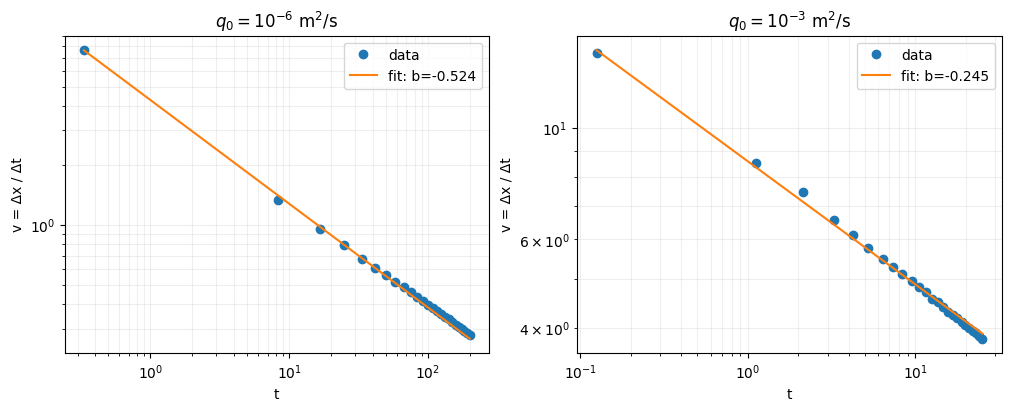

In [9]:
# -------------------------------------------------------------------
# Velocity versus duration
# -------------------------------------------------------------------

def calc_velocity(front, t, n=25):
    idx = np.linspace(1, len(front) - 1, min(n, len(front) - 1), dtype=int)
    dt = t[idx]
    v = (front[idx]) / dt
    mask = (dt > 0) & np.isfinite(v)
    return dt[mask], v[mask]

def fit_velocity_for_run(fp, buffer=1.0):
    r = analyze_run(fp, buffer=buffer)
    T, V = calc_velocity(r["front"], r["t"])
    (a, b), _ = curve_fit(power_law, T, V, p0=(V[0], -0.5))
    return T, V, a, b

# ---- runs to compare ----
fp1 = result_dir / "run-q-1e-06.hdf5"
fp2 = result_dir / "run-q-1e-03.hdf5"

T1, V1, a1, b1 = fit_velocity_for_run(fp1, buffer=1.0)
T2, V2, a2, b2 = fit_velocity_for_run(fp2, buffer=1.0)

# ---- combined plot ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax1.loglog(T1, V1, "o", label="data")
ax1.loglog(T1, power_law(T1, a1, b1), "-", label=f"fit: b={b1:.3f}")
ax1.set_title(r"$q_0 = 10^{-6}$ m$^2$/s")
ax1.set_xlabel("t")
ax1.set_ylabel("v = Δx / Δt")
ax1.grid(True, which="both", alpha=0.2)
ax1.legend()

ax2.loglog(T2, V2, "o", label="data")
ax2.loglog(T2, power_law(T2, a2, b2), "-", label=f"fit: b={b2:.3f}")
ax2.set_title(r"$q_0 = 10^{-3}$ m$^2$/s")
ax2.set_xlabel("t")
ax2.set_ylabel("v = Δx / Δt")
ax2.grid(True, which="both", alpha=0.2)
ax2.legend()

plt.show()